# Data Cleaning in Python — Exercise

**Course:** Intro to Data Mining  
**Dataset:** Heart Failure Prediction dataset (loaded from a public URL — no file downloads needed!)  

---


# YOUR TURN: Practice Exercise

Now apply the same data cleaning pipeline from the Titanic exercise to a **new dataset**: the **Heart Failure Prediction** dataset.

This dataset combines 5 heart disease databases (918 patients total) and contains medical information about patients and whether or not they have heart disease. It has **text columns that need encoding**, potential outliers, and some tricky data quality issues — perfect for practicing everything we just learned.

**Your tasks** (follow the same steps from above):

1. Load the data and take a first look
2. Understand the data types and structure
3. Get descriptive statistics
4. Check for duplicates
5. Handle missing values (decide: drop column, drop row, or impute?)
6. Encode any categorical (`object`) columns
7. Detect and handle outliers
8. Scale the numerical features

The starter code below loads the dataset for you. The rest is up to you!

> **Hints:** Pay close attention to `.describe()` — not all missing values show up as NaN! Also, this dataset was made by combining multiple hospital databases, so check for duplicates.

### About the Heart Failure Prediction Dataset

| Column | Description | Type |
|--------|-------------|------|
| Age | Age in years | Numerical |
| Sex | M = Male, F = Female | Categorical |
| ChestPainType | TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic | Categorical |
| RestingBP | Resting blood pressure (mm Hg) | Numerical |
| Cholesterol | Serum cholesterol (mg/dl) | Numerical |
| FastingBS | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Numerical |
| RestingECG | Normal, ST = ST-T wave abnormality, LVH = left ventricular hypertrophy | Categorical |
| MaxHR | Maximum heart rate achieved | Numerical |
| ExerciseAngina | Y = Yes, N = No | Categorical |
| Oldpeak | ST depression induced by exercise | Numerical |
| ST_Slope | Up = upsloping, Flat = flat, Down = downsloping | Categorical |
| HeartDisease | 1 = heart disease, 0 = no heart disease (TARGET) | Numerical |

### Step 1: Load the data

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# The Heart Failure Prediction dataset — loaded from a public GitHub URL
# (Originally from Kaggle, combining 5 UCI heart disease databases)
url = 'https://raw.githubusercontent.com/xpy-10/DataSet/main/heart.csv'

heart = pd.read_csv(url)

print(f'Dataset shape: {heart.shape[0]} rows x {heart.shape[1]} columns')
heart.head()

Dataset shape: 918 rows x 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Step 2: Check data types and structure

Use `.info()` to see the data types and count non-null values.

In [62]:
# YOUR CODE HERE
heart.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Step 3: Descriptive statistics

Use `.describe()`. Look for anything surprising in the min, max, or mean values.

In [63]:
# YOUR CODE HERE
heart.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Step 4: Check for duplicates

How many duplicate rows are there? If any, remove them.

In [64]:
# YOUR CODE HERE
heart.duplicated().sum()
heart = heart.drop_duplicates()


### Step 5: Handle missing values

Check the percentage of missing values per column. Then decide what to do:
- Drop columns that are mostly missing
- Drop rows if very few are missing
- Impute (fill) with mean or median if a moderate amount is missing

In [65]:
# YOUR CODE HERE
# Step 1: Find missing value percentages
(heart.isnull().sum() / len(heart)) * 100

print(missingval[missingval > 0])
# Step 2: Decide and apply your strategy for each column with missing values

# Drop columns that aren't useful for analysis
cols_to_drop = ['FastingBS']
df_clean = heart.drop(columns=cols_to_drop)

print(f'Shape before: {heart.shape}')
print(f'Shape after:  {heart_clean.shape}')
heart_clean.head()



Series([], dtype: float64)
Shape before: (918, 12)
Shape after:  (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Step 6: Encode categorical variables

Check if any columns are `object` type. If so, decide whether to use label encoding or one-hot encoding.

Hint: Look at `.info()` output — how many unique values does each `object` column have?

In [66]:
# YOUR CODE HERE
# Hint: Check for object columns with:
heart.select_dtypes(include='object').columns
#
# For 2 categories: heart['col'] = heart['col'].map({'val1': 0, 'val2': 1})
heart = pd.get_dummies(heart, columns=['Sex', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)
#
# Think about which columns have 2 categories vs. 3+ categories


### Step 7: Detect and handle outliers

Pick 2-3 numerical columns (e.g., `trestbps`, `chol`, `thalach`). Create box plots and use the IQR method.

Remember: think about whether outliers are real data or errors before removing them!

Age:
  Q1 = 47.00, Q3 = 60.00, IQR = 13.00
  Lower bound = 27.50, Upper bound = 79.50
  Number of outliers: 0 (0.0%)

HeartDisease:
  Q1 = 0.00, Q3 = 1.00, IQR = 1.00
  Lower bound = -1.50, Upper bound = 2.50
  Number of outliers: 0 (0.0%)


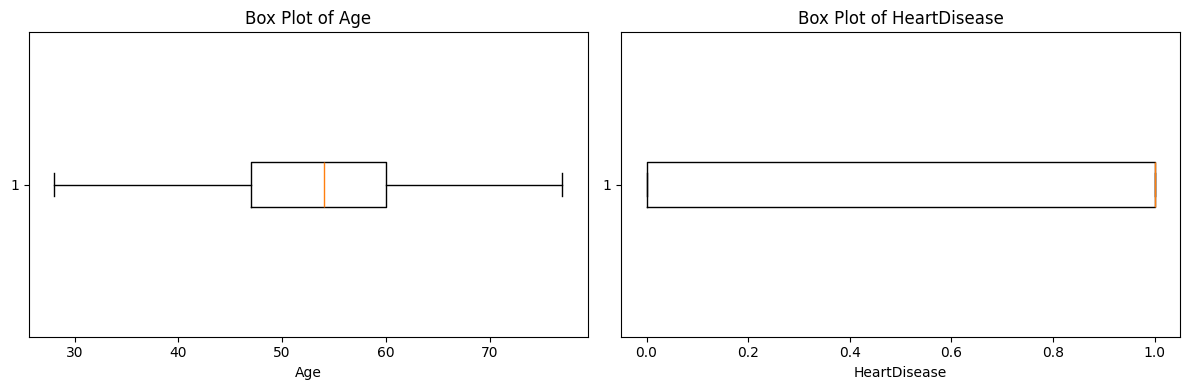

In [67]:
# YOUR CODE HERE
# Hint: You can reuse the detect_outliers_iqr function from above
# Then create box plots with plt.boxplot()

def detect_outliers_iqr(data, column):
    """Detect outliers using the IQR method. Returns a boolean mask."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)

    print(f'{column}:')
    print(f'  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
    print(f'  Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}')
    print(f'  Number of outliers: {outliers.sum()} ({outliers.sum()/len(data)*100:.1f}%)')
    return outliers

age_outliers = detect_outliers_iqr(heart_clean, 'Age')
print()
fare_outliers = detect_outliers_iqr(heart_clean, 'HeartDisease')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(heart_clean['Age'], vert=False)
axes[0].set_xlabel('Age')
axes[0].set_title('Box Plot of Age')

axes[1].boxplot(heart_clean['HeartDisease'], vert=False)
axes[1].set_xlabel('HeartDisease')
axes[1].set_title('Box Plot of HeartDisease')

plt.tight_layout()
plt.show()


### Step 8: Scale the numerical features

Apply Min-Max scaling to the numerical columns (not the target column).

In [68]:
# YOUR CODE HERE
# Hint: Follow the same pattern from Section 8 of the tutorial


# We exclude 'Survived' (target) and the one-hot columns (already 0/1)
num_cols_to_scale = ['Age']

# Make a copy so we don't modify our cleaned data
df_scaled = heart_clean.copy()

# Apply Min-Max scaling
scaler = MinMaxScaler()
df_scaled[num_cols_to_scale] = scaler.fit_transform(df_scaled[num_cols_to_scale])

print('Scaled data (first 5 rows):')
df_scaled.head()


Scaled data (first 5 rows):


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,0.428571,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,0.183673,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,0.408163,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,0.530612,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Reflection Questions

After completing the exercise, answer these questions (add a text cell or answer here):

1. How did the Heart Disease dataset compare to the Titanic dataset in terms of data quality? - It was a bit more irritating to work with.
2. Which missing value strategy did you use, and why? I dropped the values marked with 0, it seemed sufficient.
3. Did you find any outliers? Did you remove them? Why or why not? - No, and thus they were not removed. Therefore, the values left are insignificant enough to be ignored.
4. If you were building a model to predict heart disease, which columns do you think would be most important? - Age, most certainly.

---
*Great work! You now have hands-on experience with a complete data cleaning pipeline.* Dr. Thompson